In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

In [5]:
llm=ChatGroq(model='llama-3.3-70b-versatile')

In [6]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [7]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [8]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [9]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or having a rough demeanor.\n\nThe joke sets up the expectation that the pizza is in a bad mood, and the punchline subverts this by using the word "crusty" in a way that references both the pizza\'s physical characteristics (its crust) and its emotional state (being grumpy). The wordplay creates a clever and amusing connection between the setup and the punchline, making it a lighthearted and humorous joke.'}

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or having a rough demeanor.\n\nThe joke sets up the expectation that the pizza is in a bad mood, and the punchline subverts this by using the word "crusty" in a way that references both the pizza\'s physical characteristics (its crust) and its emotional state (being grumpy). The wordplay creates a clever and amusing connection between the setup and the punchline, making it a lighthearted and humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d740-0ae4-68fa-8002-475ff90f8b59'}}, metadata={'so

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or having a rough demeanor.\n\nThe joke sets up the expectation that the pizza is in a bad mood, and the punchline subverts this by using the word "crusty" in a way that references both the pizza\'s physical characteristics (its crust) and its emotional state (being grumpy). The wordplay creates a clever and amusing connection between the setup and the punchline, making it a lighthearted and humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d740-0ae4-68fa-8002-475ff90f8b59'}}, metadata={'s

In [13]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'explanation': 'This joke is a play on words, using the physical properties of spaghetti to make a humorous comment about relationships. \n\nSpaghetti is a type of long, thin, and flexible pasta that can easily become tangled or knotted. In the joke, the spaghetti\'s fear of getting "tangled up" has a double meaning. On one hand, it refers to the literal possibility of the spaghetti becoming physically entangled with something else. \n\nOn the other hand, the phrase "tangled up" is also an idiomatic expression that means to become deeply involved or complicated in a situation, often in a way that is difficult to escape. In the context of relationships, "getting tangled up" can imply becoming overly enmeshed or entangled with one\'s partner, losing one\'s sense of identity or autonomy.\n\nThe joke relies on this wordplay to create a humorous conn

In [14]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or having a rough demeanor.\n\nThe joke sets up the expectation that the pizza is in a bad mood, and the punchline subverts this by using the word "crusty" in a way that references both the pizza\'s physical characteristics (its crust) and its emotional state (being grumpy). The wordplay creates a clever and amusing connection between the setup and the punchline, making it a lighthearted and humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d740-0ae4-68fa-8002-475ff90f8b59'}}, metadata={'so

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or having a rough demeanor.\n\nThe joke sets up the expectation that the pizza is in a bad mood, and the punchline subverts this by using the word "crusty" in a way that references both the pizza\'s physical characteristics (its crust) and its emotional state (being grumpy). The wordplay creates a clever and amusing connection between the setup and the punchline, making it a lighthearted and humorous joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d740-0ae4-68fa-8002-475ff90f8b59'}}, metadata={'s

In [18]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f13d740-04a6-6bd2-8001-32c644342770"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f13d740-04a6-6bd2-8001-32c644342770'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-21T11:19:45.557387+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d740-0237-666c-8000-c80653dd7df5'}}, tasks=(PregelTask(id='d2039404-a1a3-8b26-cd98-81570d951df4', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'The joke relies on a play on words to create humor. "Crusty" has a double meaning here:\n\n1. In baking, the crust refers to the outer layer of a pizza, which is typically crispy and golden brown.\n2. In everyday language, "crusty" can also describe someone or something that is irritable, grumpy, or hav

In [19]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f13d740-04a6-6bd2-8001-32c644342770"}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. The term "crusty" has a double meaning here. \n\nIn one sense, the crust refers to the outer layer of a pizza, which is typically made of baked dough. However, "crusty" can also be used to describe someone who is irritable, gruff, or in a bad mood. \n\nThe joke relies on this wordplay to create a pun, where the expected meaning of "crusty" (relating to the pizza\'s crust) is subverted to also imply that the pizza is in a bad mood (feeling cranky or irritable). This unexpected twist creates the humor in the joke.'}

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. The term "crusty" has a double meaning here. \n\nIn one sense, the crust refers to the outer layer of a pizza, which is typically made of baked dough. However, "crusty" can also be used to describe someone who is irritable, gruff, or in a bad mood. \n\nThe joke relies on this wordplay to create a pun, where the expected meaning of "crusty" (relating to the pizza\'s crust) is subverted to also imply that the pizza is in a bad mood (feeling cranky or irritable). This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d746-d71a-6306-8002-b2793d790527'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-21T11:22:48.686037+00:00

In [26]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f13d74b-8112-62ce-8003-4843b1c8930d", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13d74c-2831-66f4-8004-6f92a67a90d6'}}

In [28]:
#fault tolerance

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

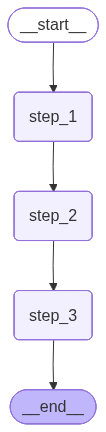

In [30]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}


# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph


In [31]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [33]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


KeyboardInterrupt: 

In [34]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d760-69f7-61b0-8001-bcae0beceb96'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-21T11:34:15.174385+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d760-69f4-688e-8000-c4ecca87a138'}}, tasks=(PregelTask(id='2c56c7fa-7afb-fd05-43f8-b36e5dc0541d', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f13d760-69f4-688e-8000-c4ecca87a138'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-21T11:34:15.173333+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch